# P1: Import of the data

In [126]:
#python3.12 pip install -r /cs/home/anp4/Desktop/Recognition-of-Emotions---AI-Model/requirement.txt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import glob
import os
import sys
import site
import seaborn as sns
import tensorflow as tf
import cv2
from tensorflow.python.client import device_lib

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [127]:
import keras
print(keras.__version__)

3.14.1


In [128]:
# Source - https://stackoverflow.com/a/67504607
# Posted by Briar Campbell, modified by community. See post 'Timeline' for change history
# Retrieved 2026-05-27, License - CC BY-SA 4.0
# Check for Nvidia GPU

import subprocess

try:
    subprocess.check_output('nvidia-smi')
    print('Nvidia GPU detected\n')
    print(pd.DataFrame(subprocess.check_output('nvidia-smi').decode('utf-8').split('\n')))
except (subprocess.CalledProcessError, FileNotFoundError):
    print('No Nvidia GPU in system')
except Exception as e:
    print(f'An unexpected error occurred: {e}')

Nvidia GPU detected

                                                    0
0                     Wed May 27 23:20:59 2026       
1   +---------------------------------------------...
2   | NVIDIA-SMI 595.71.05              Driver Ver...
3   +-----------------------------------------+---...
4   | GPU  Name                 Persistence-M | Bu...
5   | Fan  Temp   Perf          Pwr:Usage/Cap |   ...
6   |                                         |   ...
7   |=========================================+===...
8   |   0  NVIDIA GeForce RTX 3060        Off |   ...
9   |  0%   50C    P8             22W /  170W |   ...
10  |                                         |   ...
11  +-----------------------------------------+---...
12                                                   
13  +---------------------------------------------...
14  | Processes:                                  ...
15  |  GPU   GI   CI              PID   Type   Pro...
16  |        ID   ID                              ...
17  |==

In [129]:
# Code generated by Claude, on 2026-05-27
import subprocess, tensorflow as tf

print("=== Driver/CUDA ===")
subprocess.run(["nvidia-smi"])

print("\n=== TF version ===", tf.__version__)
print("=== GPUs vus par TF ===", tf.config.list_physical_devices('GPU'))

import logging
logging.getLogger('tensorflow').setLevel(logging.DEBUG)
tf.config.list_physical_devices('GPU')

=== Driver/CUDA ===
Wed May 27 23:20:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060        Off |   00000000:01:00.0  On |                  N/A |
|  0%   50C    P8             22W /  170W |    3361MiB /  12288MiB |     33%      Default |
|                                         |                        |                  N/A |
+---------------------------

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [130]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print("Memory growth enabled for GPU")

Memory growth enabled for GPU


In [131]:
def evaluate_metric(y_true, y_pred, class_names):
    
    cm = confusion_matrix(y_true, y_pred)
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    # Affichage de la matrice de confusion
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', 
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title('Confusion Matrix')
    plt.show()

    metrics = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }
    return metrics

In [132]:
train_dataset_main = "../data/train"
test_dataset_main = "../data/test"
valid_dataset_main = "..//data/valid"

In [133]:
# Tiryaki, S. (s.d.). Facial Expressions Classification. 
# Link: https://www.kaggle.com/code/sahintiryaki/facial-expressions-classification
def create_dataset_df(main_path, dataset_name):
    print(f"{dataset_name} is creating ...")
    df = {"img_path":[],"class_names":[]}
    for class_names in os.listdir(main_path):
        # Select only the emotions we want to detect.
        if class_names in {"happy", "angry", "neutral", "sad", "surprise"}:
            for img_path in glob.glob(f"{main_path}/{class_names}/*"):
                df["img_path"].append(img_path)
                df["class_names"].append(class_names)
    df = pd.DataFrame(df)
    print(f"{dataset_name} is created !")
    return df

In [134]:
train_df = create_dataset_df(train_dataset_main, "Train dataset")
train_df.size

Train dataset is creating ...
Train dataset is created !


169756

In [135]:
test_df = create_dataset_df(test_dataset_main, "Test dataset")
test_df.size

Test dataset is creating ...
Test dataset is created !


32020

In [136]:
valid_df = create_dataset_df(valid_dataset_main, "Valid dataset")
valid_df.size

Valid dataset is creating ...
Valid dataset is created !


32082

In [137]:
train_df.head()

,img_path,class_names
0,../data/train/happy/80288Exp3awe_grandmother_1...,happy
1,../data/train/happy/65014Exp3astound_worker_96...,happy
2,../data/train/happy/53132Exp3amazed_African_61...,happy
3,../data/train/happy/Happy.2985.jpg,happy
4,../data/train/happy/70972Exp3awe_student_343.jpg,happy


In [138]:
def vizualizing_images(df,n_rows,n_cols):
    plt.figure(figsize=(10,10))
    for i in range(n_rows*n_cols):
        index = np.random.randint(0, len(df))
        img = cv2.imread(df.img_path[index])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        class_nm = df.class_names[index]
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(img, plt.cm.gray)
        plt.title(class_nm)
    plt.show()

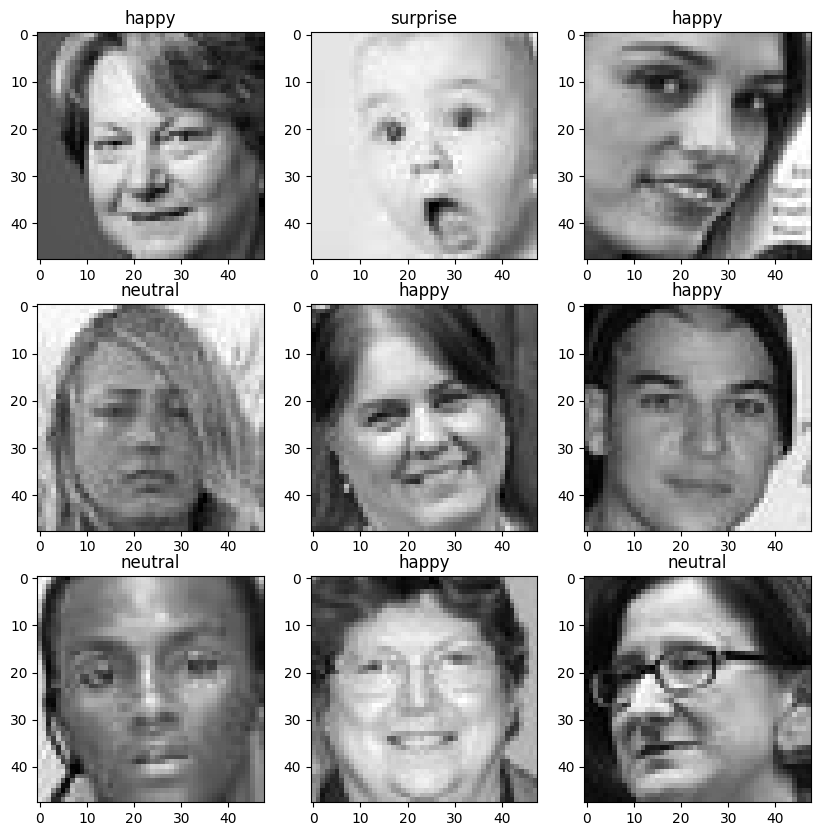

In [139]:
vizualizing_images(train_df, 3, 3)

# P2: Build the CNN (ResNet)

In [148]:
# Defining hyperparameters
BATCH_SIZE = 64
EPOCHS = 40
IMG_CHANNEL = 1
IMG_W, IMG_H = 48, 48
LEARNING_RATE = 1e-3 # base one 

In [141]:
# EfficientNet BO as a model
B_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_W, IMG_H, 3),
)

In [ ]:

# Use a sequential model
# Architecture is inspired by VGG16 (old model from undergrad project):
# -fewer layers + regularization to prevent overfitting on our small dataset.
model = keras.Sequential([
    # cLayer 1 - 3 blocs de convolution + max pooling + batch normalization + dropout
    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same',
                        input_shape=(IMG_W, IMG_H, IMG_CHANNEL)),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Dropout(0.25),

    # Layer 2 - 2 convolutional layers + max pooling + batch normalization + dropout
    keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Dropout(0.25),

    # Layer 3 - 2 convolutional layers + max pooling + batch normalization + dropout
    keras.layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Dropout(0.25),

    # Classification head
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(5, activation='softmax')
])

# Compile the model with a higher learning rate for training from scratch; we will lower it later for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/home/anp4/.local/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)              │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,918,597 (11.13 MB)

 Trainable params: 2,916,805 (11.13 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [143]:
# Tranning the model
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# We don't need data augmentation for the validation and test sets, only rescaling.
test_datagen = ImageDataGenerator(rescale=1./255)

# Training generator with data augmentation
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='img_path',
    y_col='class_names',
    target_size=(IMG_W, IMG_H),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Validation generator
valid_generator = train_datagen.flow_from_dataframe(
    dataframe = valid_df,
    x_col = 'img_path',
    y_col = 'class_names',
    target_size=(IMG_W, IMG_H),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Test generator
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='img_path',
    y_col='class_names',
    target_size=(IMG_W, IMG_H),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Early stopping for overfitting
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

# Compute class weights to handle class imbalance
classes = np.unique(['happy', 'angry', 'neutral', 'sad', 'surprise'])
weight = compute_class_weight(class_weight='balanced', classes=classes, y=train_df['class_names'])
class_weights_dict = dict(enumerate(weight))

# Launching the training process
history = model.fit(
    train_generator,
    epochs=40,
    validation_data=valid_generator,
    callbacks=[early_stopping],
    class_weight=class_weights_dict
)

Found 84878 validated image filenames belonging to 5 classes.
Found 16041 validated image filenames belonging to 5 classes.
Found 16010 validated image filenames belonging to 5 classes.
Epoch 1/40


I0000 00:00:1779920463.920090  235911 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_475762__.83


1003/1327 ━━━━━━━━━━━━━━━━━━━━ 27s 85ms/step - accuracy: 0.2709 - loss: 2.2274

I0000 00:00:1779920553.358358  235912 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_475762__.83


1327/1327 ━━━━━━━━━━━━━━━━━━━━ 143s 104ms/step - accuracy: 0.3084 - loss: 1.9619 - val_accuracy: 0.3558 - val_loss: 1.6968
Epoch 2/40
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 131s 99ms/step - accuracy: 0.3877 - loss: 1.5886 - val_accuracy: 0.3737 - val_loss: 1.7433
Epoch 3/40
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 126s 95ms/step - accuracy: 0.4522 - loss: 1.3916 - val_accuracy: 0.4216 - val_loss: 1.4463
Epoch 4/40
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 130s 98ms/step - accuracy: 0.5011 - loss: 1.2508 - val_accuracy: 0.4430 - val_loss: 1.4095
Epoch 5/40
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 123s 93ms/step - accuracy: 0.5410 - loss: 1.1554 - val_accuracy: 0.4527 - val_loss: 1.4086
Epoch 6/40
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 132s 100ms/step - accuracy: 0.5696 - loss: 1.0967 - val_accuracy: 0.4081 - val_loss: 1.4542
Epoch 7/40
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 137s 103ms/step - accuracy: 0.5861 - loss: 1.0578 - val_accuracy: 0.4355 - val_loss: 1.4036
Epoch 8/40
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 139s 105ms/step - accuracy: 0.5982 

In [149]:
# Fine-tuning

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Early stop
early_stopping_ft = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True
)

history_ft = model.fit(
    train_generator,
    epochs=20,
    validation_data=valid_generator,
    callbacks=[early_stopping_ft],
    class_weight=class_weights_dict
)

Epoch 1/20


I0000 00:00:1779926577.508925  235909 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_694370__.83


 569/1327 ━━━━━━━━━━━━━━━━━━━━ 1:15 99ms/step - accuracy: 0.5538 - loss: 1.1513

I0000 00:00:1779926638.082726  235911 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_694370__.83


1327/1327 ━━━━━━━━━━━━━━━━━━━━ 156s 113ms/step - accuracy: 0.5739 - loss: 1.0949 - val_accuracy: 0.2471 - val_loss: 1.8215
Epoch 2/20
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 126s 95ms/step - accuracy: 0.6059 - loss: 1.0260 - val_accuracy: 0.5001 - val_loss: 1.2800
Epoch 3/20
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 147s 111ms/step - accuracy: 0.6221 - loss: 0.9980 - val_accuracy: 0.3788 - val_loss: 1.5829
Epoch 4/20
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 132s 100ms/step - accuracy: 0.6248 - loss: 0.9869 - val_accuracy: 0.5039 - val_loss: 1.2873
Epoch 5/20
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 135s 101ms/step - accuracy: 0.6428 - loss: 0.9467 - val_accuracy: 0.4679 - val_loss: 1.3545
Epoch 6/20
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 133s 100ms/step - accuracy: 0.6480 - loss: 0.9333 - val_accuracy: 0.4929 - val_loss: 1.2983
Epoch 7/20
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 130s 98ms/step - accuracy: 0.6510 - loss: 0.9238 - val_accuracy: 0.5058 - val_loss: 1.2600
Epoch 8/20
1327/1327 ━━━━━━━━━━━━━━━━━━━━ 130s 98ms/step - accuracy: 0.6564

In [150]:
checkpoint = keras.callbacks.ModelCheckpoint(
    "../models/best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks=[early_stopping, checkpoint]

251/251 ━━━━━━━━━━━━━━━━━━━━ 21s 80ms/step


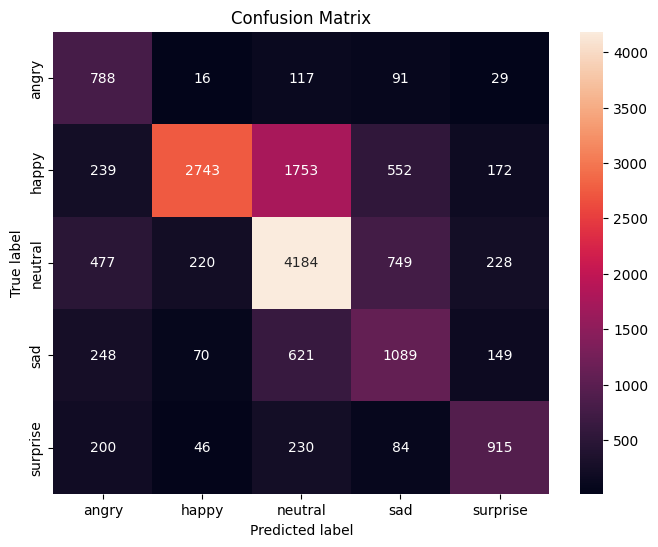

{'Accuracy': 0.6070580886945659,
 'Precision': 0.6643472588590835,
 'Recall': 0.6070580886945659,
 'F1 Score': 0.6120754633026998}

In [151]:
EMOTIONS = ['angry', 'happy', 'neutral', 'sad', 'surprise']

y_pred = model.predict(test_generator)
y_pred_classes = y_pred.argmax(axis=1)
y_true = test_generator.classes

evaluate_metric(y_true, y_pred_classes, EMOTIONS)

In [147]:
model.save("../models/emotion_recognition_model.h5")